# Case 04 — Capacity Decision Intelligence
### PROVIDENTIA Evidence Pack — capacity decision notebook

This notebook reads **only files inside this same folder**
(`decision_metrics.csv`, `policy_tradeoff.csv`, `figures/`). It does not
import `src/providentia`, does not read `data/raw/` or `data/processed/`,
and does not read anything from `case03_forecasting/`. No forecast is
recomputed and no model is trained or retrained here — every number plotted
below is an already-frozen decision-policy-simulation metric copied from
PROVIDENTIA's `reports/p6` and `reports/p7` artifacts (see
`portfolio_manifest.json` for exact source files and hashes).

**Case 04 starts where Case 03 ends.** Forecast point predictions and
80/90/95% prediction intervals are taken as an already-given input (see
`public_export/case03_forecasting/` for that evidence) — this notebook does
**not** repeat model selection or WAPE/MAE/MASE.

Sections: forecast+uncertainty as input → PI80/PI90/PI95 comparison →
exceedance vs buffer trade-off → shortfall → frozen policy ETS×PI90 →
development vs final → conclusions & limitations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

HERE = Path.cwd()
decision = pd.read_csv(HERE / "decision_metrics.csv")
tradeoff = pd.read_csv(HERE / "policy_tradeoff.csv")

print("decision_metrics.csv:", decision.shape)
print("policy_tradeoff.csv:", tradeoff.shape)
decision.head()

decision_metrics.csv: (12, 18)
policy_tradeoff.csv: (12, 10)


,evaluation_label,model_id,protection_policy_id,policy_level,evaluation_role,support_n,exceedance_rate,mean_buffer,median_buffer,mean_excess_units,median_excess_units,total_excess_units,mean_shortfall_units,median_shortfall_units,total_shortfall_units,maximum_shortfall,mean_required_capacity,continuous_exceedance_rate
0,DEVELOPMENT_DECISION_POLICY_SIMULATION,ets_aicc,PI80_POLICY,0.80,scenario,4158.0,0.093795,99.273208,67.0,105.227754,52.0,437537.0,4.116402,0.0,17116.0,1059.0,719.594276,0.097643
1,DEVELOPMENT_DECISION_POLICY_SIMULATION,ets_aicc,PI90_POLICY,0.90,reference,4158.0,0.044252,132.948533,89.5,136.688552,73.0,568351.0,1.901876,0.0,7908.0,1013.0,753.269601,0.047860
2,DEVELOPMENT_DECISION_POLICY_SIMULATION,ets_aicc,PI95_POLICY,0.95,scenario,4158.0,0.022126,164.843194,111.0,167.687831,95.0,697246.0,1.006494,0.0,4185.0,971.0,785.164262,0.023810
3,DEVELOPMENT_DECISION_POLICY_SIMULATION,lightgbm_global_full_v1,PI80_POLICY,0.80,scenario,4158.0,0.093555,100.571429,68.0,106.129870,53.0,441288.0,4.585137,0.0,19065.0,1034.0,720.027658,0.100048
4,DEVELOPMENT_DECISION_POLICY_SIMULATION,lightgbm_global_full_v1,PI90_POLICY,0.90,scenario,4158.0,0.050505,131.787398,89.0,135.116402,74.0,561814.0,2.355700,0.0,9795.0,991.0,751.243627,0.053151


## 1. Forecast + uncertainty as input

P6/P7 do not forecast — they consume point forecasts and 80/90/95%
prediction intervals already frozen by P3/P4/P5. Each interval level
defines a required monthly capacity:

```
required_capacity_integer = ceil(operational_upper_<level>)
uncertainty_buffer = required_capacity_integer − ceil(point_forecast)
```

`current_capacity` does not exist in the data and is **never invented**
(`config/p6_decision.yaml`: `current_capacity.source: none`,
`current_capacity.invent: false`).

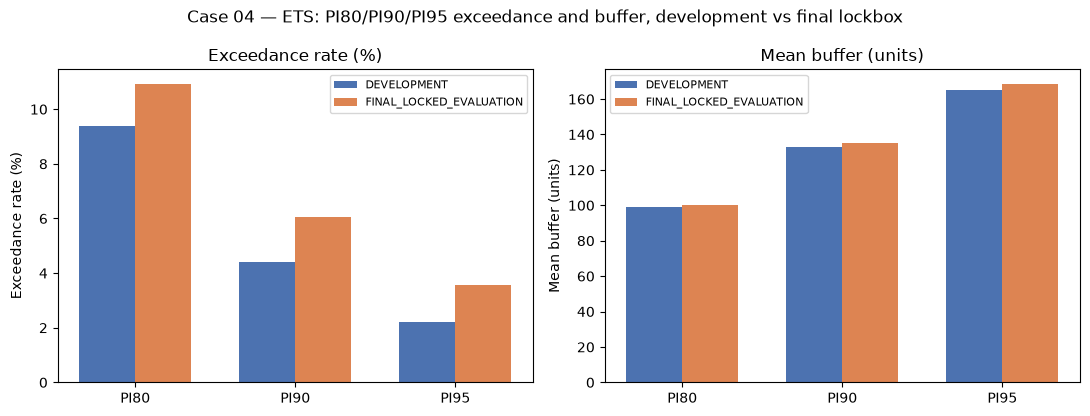

In [2]:
# --- Chart 1: PI80 / PI90 / PI95 comparison — exceedance and buffer, ETS, DEVELOPMENT vs FINAL ---
ets = decision[decision.model_id == "ets_aicc"].copy()
ets["policy_label"] = ets["protection_policy_id"].str.replace("_POLICY", "", regex=False)
policy_order = ["PI80", "PI90", "PI95"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
w = 0.35
x = range(len(policy_order))
for ax, metric, ylabel, pct in [
    (axes[0], "exceedance_rate", "Exceedance rate (%)", True),
    (axes[1], "mean_buffer", "Mean buffer (units)", False),
]:
    dev = ets[ets.evaluation_label == "DEVELOPMENT_DECISION_POLICY_SIMULATION"].set_index("policy_label").loc[policy_order, metric]
    fin = ets[ets.evaluation_label == "FINAL_LOCKED_EVALUATION"].set_index("policy_label").loc[policy_order, metric]
    scale = 100 if pct else 1
    ax.bar([i - w/2 for i in x], dev.values * scale, width=w, label="DEVELOPMENT", color="#4C72B0")
    ax.bar([i + w/2 for i in x], fin.values * scale, width=w, label="FINAL_LOCKED_EVALUATION", color="#DD8452")
    ax.set_xticks(list(x)); ax.set_xticklabels(policy_order)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
fig.suptitle("Case 04 — ETS: PI80/PI90/PI95 exceedance and buffer, development vs final lockbox")
plt.tight_layout()
plt.show()

More protection (PI80 → PI90 → PI95) monotonically **reduces exceedance at
the cost of a larger mean buffer**, in both evaluation sets. **PI90 is the
reference policy** (highlighted with a border in the trade-off chart below)
— it was chosen as a normative middle ground *before* seeing this
comparison, not selected because it optimizes either axis.

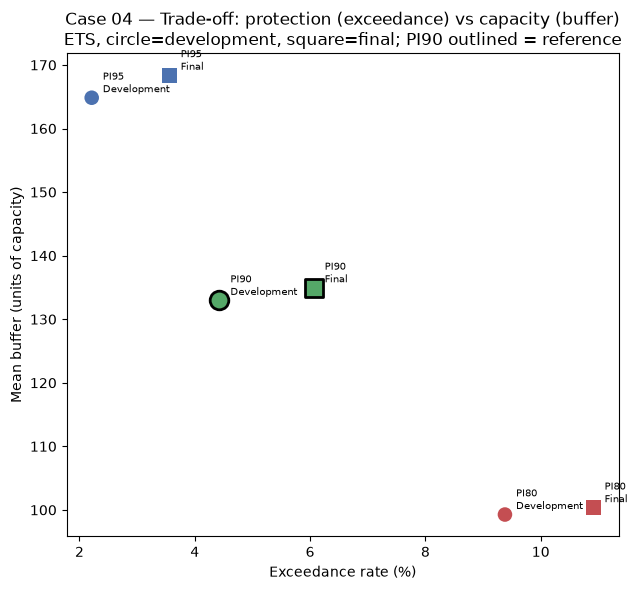

In [3]:
# --- Chart 2: exceedance vs buffer trade-off (protection vs capacity) ---
fig, ax = plt.subplots(figsize=(6.5, 6))
markers = {"DEVELOPMENT_DECISION_POLICY_SIMULATION": "o", "FINAL_LOCKED_EVALUATION": "s"}
colors = {"PI80": "#C44E52", "PI90": "#55A868", "PI95": "#4C72B0"}
for ev_label, marker in markers.items():
    sub = ets[ets.evaluation_label == ev_label].set_index("policy_label").loc[policy_order]
    for policy in policy_order:
        row = sub.loc[policy]
        is_ref = policy == "PI90"
        ax.scatter(
            row["exceedance_rate"] * 100, row["mean_buffer"],
            s=180 if is_ref else 110, marker=marker, color=colors[policy],
            edgecolors="black" if is_ref else "none", linewidths=2 if is_ref else 0,
            zorder=3 if is_ref else 2,
        )
        ax.annotate(f"{policy}\n{ev_label.split('_')[0].title()}", (row["exceedance_rate"] * 100, row["mean_buffer"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=7.5)
ax.set_xlabel("Exceedance rate (%)")
ax.set_ylabel("Mean buffer (units of capacity)")
ax.set_title("Case 04 — Trade-off: protection (exceedance) vs capacity (buffer)\nETS, circle=development, square=final; PI90 outlined = reference")
plt.tight_layout()
plt.show()

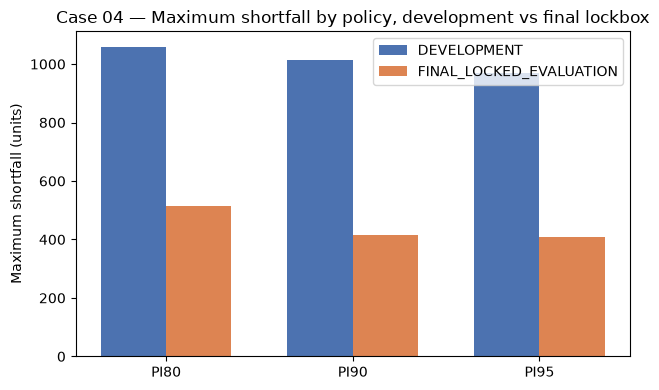

evaluation_label,DEVELOPMENT_DECISION_POLICY_SIMULATION,FINAL_LOCKED_EVALUATION
policy_label,,
PI80,1059.0,515.0
PI90,1013.0,416.0
PI95,971.0,410.0


In [4]:
# --- Chart 3: maximum shortfall by policy, development vs final ---
max_shortfall = ets.pivot(index="policy_label", columns="evaluation_label", values="maximum_shortfall").loc[policy_order]

fig, ax = plt.subplots(figsize=(6.5, 4))
x = range(len(policy_order))
ax.bar([i - w/2 for i in x], max_shortfall["DEVELOPMENT_DECISION_POLICY_SIMULATION"], width=w, label="DEVELOPMENT", color="#4C72B0")
ax.bar([i + w/2 for i in x], max_shortfall["FINAL_LOCKED_EVALUATION"], width=w, label="FINAL_LOCKED_EVALUATION", color="#DD8452")
ax.set_xticks(list(x)); ax.set_xticklabels(policy_order)
ax.set_ylabel("Maximum shortfall (units)")
ax.set_title("Case 04 — Maximum shortfall by policy, development vs final lockbox")
ax.legend()
plt.tight_layout()
plt.show()

max_shortfall

**Maximum shortfall fell substantially at every policy level on the final
lockbox** (e.g. PI90: 1,013 → 416), while exceedance rate rose modestly
(4.43% → 6.06% at PI90, see chart 1). Net picture: the final period produced
more small misses on average but no outlier miss approaching the size seen
in development. `shortfall_units` are **not** observed unmet patient demand
— they are outputs of simulating the frozen policy against a forecast, on a
period where no real capacity was ever recorded.

## 8–9. Frozen policy and final lockbox — figure

The frozen reference policy is **ETS × PI90**, fixed by `DDR-007` before the
lockbox opened. Reused figure from the final lockbox evaluation
(`reports/p7/figures/decision-exceedance-by-policy.png`, unmodified):

![Final decision by policy](figures/p7-decision-exceedance-by-policy.png)

In [5]:
# --- Self-check: exported values match the headline numbers documented in README.md / portfolio_manifest.json ---
expected = {
    ("DEVELOPMENT_DECISION_POLICY_SIMULATION", "PI90"): dict(exceedance_rate=0.0442520442520442, mean_buffer=132.94853294853294, maximum_shortfall=1013.0),
    ("FINAL_LOCKED_EVALUATION", "PI90"): dict(exceedance_rate=0.06060606060606061, mean_buffer=134.9385521885522, maximum_shortfall=416.0),
}
for (ev, policy), exp in expected.items():
    row = ets[(ets.evaluation_label == ev) & (ets.policy_label == policy)].iloc[0]
    for k, v in exp.items():
        assert abs(row[k] - v) < 1e-9, (ev, policy, k, row[k], v)
print("Self-check OK: decision_metrics.csv values match the documented ETS x PI90 headline numbers.")

Self-check OK: decision_metrics.csv values match the documented ETS x PI90 headline numbers.


## Conclusions

- Required monthly referral-handling capacity is derived from the forecast
  interval upper bound (`ceil(operational_upper_<level>)`), never from an
  observed `current_capacity` — which does not exist in this dataset.
- The PI80 → PI90 → PI95 trade-off is monotone and consistent between
  development and the final lockbox: more protection buys lower exceedance
  at the cost of a larger buffer. **PI90 is the reference policy by design
  choice, not because it is optimal on either axis.**
- On the final lockbox, exceedance under PI90 rose modestly relative to
  development (4.43% → 6.06%) while maximum shortfall fell sharply
  (1,013 → 416) — a mixed but bounded generalization gap, reported as-is.
- `post_lockbox_tuning` and `post_lockbox_selection` are `false` throughout
  — none of the final-lockbox numbers above changed the frozen `ETS × PI90`
  reference policy.
- LightGBM (sensitivity) tracks ETS closely at PI90 on the final lockbox
  (mean difference +2.64 units) — a small, non-systematic disagreement, not
  a substitute for the primary model.

## Limitations (preserve exactly when reusing this pack — full contract in `claims_contract.md`)

- **`current_capacity` is never invented.** Every capacity number here is a
  simulated requirement under a named policy, not a comparison against a
  real operational baseline.
- **Not staffing, not real hospital capacity, not a guaranteed service
  level, not monetary savings.** `excess_units` are not real idle capacity;
  `shortfall_units` are not observed unmet patient demand.
- **Referrals ≠ appointments.** The capacity unit assumes one accepted
  referral eventually requires one appointment slot; rejection, redirection,
  conversion and scheduling lag are not observed.
- **The policy was frozen before the lockbox opened**, and stayed frozen
  after opening — no tuning, no ensemble, no `max()`, no policy switch.
- Board/specialty/series cuts in the source reports are descriptive only —
  small subgroup counts do not authorize ranking hospitals or specialties.
- This pack contains no raw or processed row-level data; forecast/model
  evidence lives in `case03_forecasting/`, not here.